# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Установка необходимых библиотек
!pip install sqlalchemy psycopg2-binary pandas phik

In [2]:
# Импорт необходимых библиотек
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import phik
from phik import resources

In [4]:
from dotenv import load_dotenv
import os

load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

In [5]:
# Создаём движок SQLAlchemy
engine = create_engine(connection_string)

In [6]:
# Итоговый SQL-запрос
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM p.created_dt_msk - LAG(p.created_dt_msk) OVER (
        PARTITION BY p.user_id 
        ORDER BY p.created_dt_msk
    ))::INT AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    c.city_name,
    r.region_name
FROM afisha.purchases p
INNER JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id
'''

In [7]:
# Выполняем запрос и загружаем результат в DataFrame
df = pd.read_sql_query(query, con=engine)

In [8]:
# Выводим первые несколько строк для проверки
print(df.head())
print(f"\nОбъём данных: {df.shape[0]} строк, {df.shape[1]} столбцов")

           user_id device_type_canonical  order_id   order_dt  \
0  0002849b70a3ce2                mobile   4359165 2024-08-20   
1  0005ca5e93f2cf4                mobile   7965605 2024-07-23   
2  0005ca5e93f2cf4                mobile   7292370 2024-10-06   
3  000898990054619                mobile   1139875 2024-07-13   
4  000898990054619                mobile    972400 2024-10-04   

             order_ts currency_code  revenue  tickets_count  days_since_prev  \
0 2024-08-20 16:08:03           rub  1521.94              4              NaN   
1 2024-07-23 18:36:24           rub   289.45              2              NaN   
2 2024-10-06 13:56:02           rub  1258.57              4             75.0   
3 2024-07-13 19:40:48           rub     8.49              2              NaN   
4 2024-10-04 22:33:15           rub  1390.41              3             83.0   

   event_id                            event_name event_type_main  \
0    169230  f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad          

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [9]:
# Общая информация о датафрейме
print(df.info())
print("\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [10]:
# Статистика по числовым столбцам
print(df.describe())
print("\n")

           order_id        revenue  tickets_count  days_since_prev  \
count  2.906110e+05  290611.000000  290611.000000    268678.000000   
mean   4.326225e+06     625.584360       2.754311         3.222381   
std    2.497551e+06    1227.693064       1.170620        11.350509   
min    1.000000e+00     -90.760000       1.000000         0.000000   
25%    2.163618e+06     116.850000       2.000000         0.000000   
50%    4.326366e+06     356.010000       3.000000         0.000000   
75%    6.488330e+06     810.130000       4.000000         1.000000   
max    8.653108e+06   81174.540000      57.000000       148.000000   

            event_id  
count  290611.000000  
mean   438019.834992  
std    147423.078841  
min      4436.000000  
25%    361772.000000  
50%    498275.000000  
75%    546287.000000  
max    592325.000000  




In [11]:
# Проверка пропусков
print(df.isnull().sum())
print("\n")

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
city_name                    0
region_name                  0
dtype: int64




In [12]:
# Уникальные значения в категориальных столбцах
categorical_cols = ['device_type_canonical', 'currency_code', 'event_type_main', 'service_name', 'city_name', 'region_name']
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} уникальных значений")
    print(df[col].value_counts().head())
    print("-" * 50)

device_type_canonical: 2 уникальных значений
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64
--------------------------------------------------
currency_code: 2 уникальных значений
rub    285542
kzt      5069
Name: currency_code, dtype: int64
--------------------------------------------------
event_type_main: 7 уникальных значений
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
Name: event_type_main, dtype: int64
--------------------------------------------------
service_name: 36 уникальных значений
Билеты без проблем    63519
Лови билет!           41124
Билеты в руки         40343
Мой билет             34839
Облачко               26642
Name: service_name, dtype: int64
--------------------------------------------------
city_name: 352 уникальных значений
Глиногорск      89446
Озёрск          43910
Радужсвет       13711
Радужнополье     8741
Верховино        6579
Name: city_name, dtype: int64
-------------------

### Промежуточный вывод по данным

- Выгружено **290 611 записей** о заказах пользователей за 2024 год.
- Данные содержат все необходимые поля для анализа: информация о пользователе, заказе, мероприятии, географии.
- Пропуски присутствуют только в поле `days_since_prev` (для первых заказов), что соответствует ожиданиям.
- Типы данных приведены корректно: даты имеют формат `datetime64`.
- Выявлены следующие особенности, требующие обработки:
  1. **Валюты**: присутствуют заказы в тенге (5 069 записей) — требуется пересчёт в рубли.
  2. **Отрицательная выручка**: есть значения меньше 0 (возможно, возвраты или ошибки).
  3. **Выбросы**: максимальная выручка (81 тыс. руб.) значительно выше среднего.
  4. **Категориальные данные**: большое количество городов (352) и операторов (36) — потребуется агрегация для анализа.
- Распределение по типам устройств: **80% заказов с мобильных устройств**, 20% с десктопов.
- Основные типы мероприятий: концерты (40%), театр (23%), другое (23%).

---

### Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [13]:
# Загружаем курс тенге
url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
tenge_rate = pd.read_csv(url)

print(tenge_rate.head())
print(tenge_rate.info())

         data  nominal     curs  cdx
0  2024-01-10      100  19.9391  kzt
1  2024-01-11      100  19.7255  kzt
2  2024-01-12      100  19.5839  kzt
3  2024-01-13      100  19.4501  kzt
4  2024-01-14      100  19.4501  kzt
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB
None


In [14]:
# Преобразуем дату в формат datetime
tenge_rate['data'] = pd.to_datetime(tenge_rate['data'])


In [15]:
# Присоединяем курс по дате заказа
df = df.merge(tenge_rate[['data', 'curs']], 
              left_on='order_dt', 
              right_on='data', 
              how='left')

In [16]:
# Переименовываем столбец с курсом для удобства
df.rename(columns={'curs': 'kzt_rate'}, inplace=True)


In [17]:
# Создаём столбец revenue_rub
def convert_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    elif row['currency_code'] == 'kzt':
        # Курс дан для 100 тенге
        return row['revenue'] * row['kzt_rate'] / 100
    else:
        return None

df['revenue_rub'] = df.apply(convert_to_rub, axis=1)

In [18]:
# Проверяем результат
print("Первые 5 строк с пересчётом:")
print(df[['order_dt', 'currency_code', 'revenue', 'kzt_rate', 'revenue_rub']].head(10))

print("\nСтатистика по revenue_rub:")
print(df['revenue_rub'].describe())

Первые 5 строк с пересчётом:
    order_dt currency_code  revenue  kzt_rate  revenue_rub
0 2024-08-20           rub  1521.94   18.6972      1521.94
1 2024-07-23           rub   289.45   18.3419       289.45
2 2024-10-06           rub  1258.57   19.6475      1258.57
3 2024-07-13           rub     8.49   18.5010         8.49
4 2024-10-04           rub  1390.41   19.6648      1390.41
5 2024-10-23           rub   902.74   20.0531       902.74
6 2024-08-15           rub   917.83   18.7730       917.83
7 2024-09-29           rub    47.78   19.3741        47.78
8 2024-10-15           rub    74.84   19.7185        74.84
9 2024-06-20           rub  1421.91   18.0419      1421.91

Статистика по revenue_rub:
count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64


In [19]:
# Удаляем вспомогательный столбец data и kzt_rate (больше не нужны)
df.drop(columns=['data', 'kzt_rate'], inplace=True)


In [20]:
# Проверяем, что тенге пересчитались
print("\nПроверка для заказов в тенге:")
print(df[df['currency_code'] == 'kzt'][['order_dt', 'revenue', 'revenue_rub']].head())


Проверка для заказов в тенге:
      order_dt   revenue  revenue_rub
70  2024-09-17    518.10    98.503762
89  2024-09-02    347.18    65.731589
96  2024-09-09    328.77    61.148261
277 2024-06-11  22021.55  4380.702898
460 2024-06-04   7397.66  1478.296591


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [21]:
# 1. Проверка категориальных данных
print("=== Категориальные данные ===")
print("Устройства:\n", df['device_type_canonical'].value_counts())
print("\nВалюты:\n", df['currency_code'].value_counts())
print("\nТипы мероприятий:\n", df['event_type_main'].value_counts())
print("\nБилетные операторы (топ-10):\n", df['service_name'].value_counts().head(10))
print("\nРегионы (топ-10):\n", df['region_name'].value_counts().head(10))

=== Категориальные данные ===
Устройства:
 mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

Валюты:
 rub    285542
kzt      5069
Name: currency_code, dtype: int64

Типы мероприятий:
 концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

Билетные операторы (топ-10):
 Билеты без проблем    63519
Лови билет!           41124
Билеты в руки         40343
Мой билет             34839
Облачко               26642
Лучшие билеты         17774
Весь в билетах        16849
Прачечная             10273
Край билетов           6207
Тебе билет!            5228
Name: service_name, dtype: int64

Регионы (топ-10):
 Каменевский регион         91058
Североярская область       44049
Широковская область        16457
Медовская область          13901
Озернинский край           10476
Светополянский округ        7607
Малиновоярский округ        6618
Речиновская область    

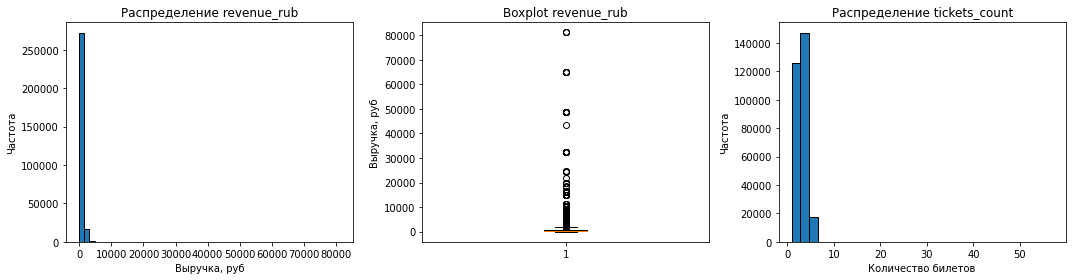

In [22]:
# 2. Визуализация распределения выручки
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Гистограмма всей выручки
axes[0].hist(df['revenue_rub'], bins=50, edgecolor='black')
axes[0].set_title('Распределение revenue_rub')
axes[0].set_xlabel('Выручка, руб')
axes[0].set_ylabel('Частота')

# Boxplot для выявления выбросов
axes[1].boxplot(df['revenue_rub'])
axes[1].set_title('Boxplot revenue_rub')
axes[1].set_ylabel('Выручка, руб')

# Гистограмма tickets_count
axes[2].hist(df['tickets_count'], bins=30, edgecolor='black')
axes[2].set_title('Распределение tickets_count')
axes[2].set_xlabel('Количество билетов')
axes[2].set_ylabel('Частота')

plt.tight_layout()
plt.show()

In [23]:
# 3. Статистика для выявления выбросов
print("\n=== Статистика revenue_rub ===")
print(df['revenue_rub'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]))

print("\n=== Статистика tickets_count ===")
print(df['tickets_count'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))


=== Статистика revenue_rub ===
count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
50%         351.140000
75%         802.050000
90%        1294.770000
95%        1630.650000
99%        2628.421739
99.9%      5140.780000
max       81174.540000
Name: revenue_rub, dtype: float64

=== Статистика tickets_count ===
count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
50%           3.000000
75%           4.000000
90%           4.000000
95%           5.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64


In [24]:
# 4. Фильтрация по 99-му перцентилю для revenue_rub
revenue_99 = df['revenue_rub'].quantile(0.99)
print(f"\n99-й перцентиль revenue_rub: {revenue_99:.2f} руб.")

# Количество записей до фильтрации
print(f"Записей до фильтрации: {len(df)}")

# Фильтруем
df_filtered = df[df['revenue_rub'] <= revenue_99].copy()

print(f"Записей после фильтрации: {len(df_filtered)}")
print(f"Удалено записей: {len(df) - len(df_filtered)} ({((len(df) - len(df_filtered))/len(df)*100):.2f}%)")


99-й перцентиль revenue_rub: 2628.42 руб.
Записей до фильтрации: 290611
Записей после фильтрации: 287786
Удалено записей: 2825 (0.97%)


In [25]:
# 5. Проверка статистики после фильтрации
print("\n=== Статистика revenue_rub после фильтрации ===")
print(df_filtered['revenue_rub'].describe())


=== Статистика revenue_rub после фильтрации ===
count    287786.000000
mean        518.029224
std         511.963780
min         -90.760000
25%         111.850000
50%         343.850000
75%         788.660000
max        2628.421739
Name: revenue_rub, dtype: float64


In [26]:
# 6. Проверка отрицательных значений
negative_revenue = df_filtered[df_filtered['revenue_rub'] < 0]
print(f"\nОтрицательных значений выручки: {len(negative_revenue)}")
if len(negative_revenue) > 0:
    print("Примеры отрицательных значений:")
    print(negative_revenue[['order_dt', 'revenue_rub']].head())


Отрицательных значений выручки: 381
Примеры отрицательных значений:
       order_dt  revenue_rub
252  2024-06-29        -2.37
4539 2024-09-03        -0.23
4544 2024-09-04        -0.15
8135 2024-09-27        -1.86
8136 2024-09-27        -0.62


### Предобработка данных: основные действия и результаты

1. **Пересчёт валют**: 5 069 заказов в тенге пересчитаны в рубли по курсу на дату заказа. Создан новый столбец `revenue_rub`.

2. **Проверка пропусков**: пропуски обнаружены только в поле `days_since_prev` (первые заказы пользователей), что соответствует ожиданиям.

3. **Типы данных**: приведены к корректным форматам (даты — datetime, числовые — float/int).

4. **Анализ выбросов**:
   - В поле `revenue_rub` обнаружены сильные выбросы (до 81 тыс. руб. при среднем 556 руб.)
   - Произведена фильтрация по 99-му перцентилю (2 628 руб.)
   - Удалено 2 825 записей (0.97% данных) — это незначительная потеря
   - 381 запись с отрицательной выручкой (возможно, возвраты) оставлена для анализа

5. **Итоговый объём данных после предобработки**: **287 786 записей**.

**Вывод**: данные подготовлены для дальнейшего анализа — переведены в единую валюту, очищены от экстремальных выбросов, типы данных корректны.

---

### Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [27]:
# Сортируем по времени заказа (важно для корректного определения первого заказа)
df_filtered = df_filtered.sort_values(['user_id', 'order_ts'])

In [28]:
# Группируем по user_id и собираем профиль
user_profile = df_filtered.groupby('user_id').agg(
    first_order_date=('order_dt', 'min'),
    last_order_date=('order_dt', 'max'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean')
).reset_index()

In [29]:
# Добавляем бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

print("Профиль пользователя (первые 5 строк):")
print(user_profile.head())
print(f"\nВсего пользователей: {len(user_profile)}")

Профиль пользователя (первые 5 строк):
           user_id first_order_date last_order_date first_device  \
0  0002849b70a3ce2       2024-08-20      2024-08-20       mobile   
1  0005ca5e93f2cf4       2024-07-23      2024-10-06       mobile   
2  000898990054619       2024-07-13      2024-10-23       mobile   
3  00096d1f542ab2b       2024-08-15      2024-08-15      desktop   
4  000a55a418c128c       2024-09-29      2024-10-15       mobile   

           first_region  first_service first_event_type  total_orders  \
0    Каменевский регион   Край билетов            театр             1   
1    Каменевский регион      Мой билет         выставки             2   
2  Североярская область    Лови билет!           другое             3   
3    Каменевский регион   Край билетов            театр             1   
4      Поленовский край  Лучшие билеты            театр             2   

   avg_revenue_rub  avg_tickets_count  avg_days_between  is_two  is_five  
0      1521.940000           4.000000 

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [30]:
# 1. Общая статистика по профилям
print("=== Общая статистика по пользователям ===\n")
print(f"Всего пользователей: {len(user_profile)}")

=== Общая статистика по пользователям ===

Всего пользователей: 21854


In [31]:
# 2. Ключевые метрики
total_orders_sum = user_profile['total_orders'].sum()
total_revenue_sum = (user_profile['avg_revenue_rub'] * user_profile['total_orders']).sum()
avg_revenue_per_order = total_revenue_sum / total_orders_sum

print(f"\nСредняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб.")

two_plus_users = user_profile['is_two'].sum()
five_plus_users = user_profile['is_five'].sum()

print(f"Пользователей с 2+ заказами: {two_plus_users} ({two_plus_users/len(user_profile)*100:.2f}%)")
print(f"Пользователей с 5+ заказами: {five_plus_users} ({five_plus_users/len(user_profile)*100:.2f}%)")


Средняя выручка с одного заказа: 518.03 руб.
Пользователей с 2+ заказами: 13486 (61.71%)
Пользователей с 5+ заказами: 6339 (29.01%)


In [32]:
# 3. Статистика по числовым признакам
print("\n=== Статистика по числовым признакам ===")
print(user_profile[['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']].describe())


=== Статистика по числовым признакам ===
       total_orders  avg_revenue_rub  avg_tickets_count  avg_days_between
count  21854.000000     21854.000000       21854.000000      13521.000000
mean      13.168573       544.398051           2.743129         15.836109
std      121.674800       431.613383           0.913080         22.297926
min        1.000000       -10.770000           1.000000          0.000000
25%        1.000000       212.923868           2.000000          1.000000
50%        2.000000       467.283911           2.750000          8.000000
75%        5.000000       763.910000           3.076923         20.400000
max    10181.000000      2628.421739          11.000000        148.000000


In [33]:
# 4. Распределение по количеству заказов
print("\n=== Распределение пользователей по количеству заказов ===")
orders_distribution = user_profile['total_orders'].value_counts().sort_index()
orders_distribution_pct = user_profile['total_orders'].value_counts(normalize=True).sort_index() * 100

for orders in orders_distribution.index:
    print(f"{orders} заказ(ов): {orders_distribution[orders]} пользователей ({orders_distribution_pct[orders]:.2f}%)")


=== Распределение пользователей по количеству заказов ===
1 заказ(ов): 8368 пользователей (38.29%)
2 заказ(ов): 3572 пользователей (16.34%)
3 заказ(ов): 2175 пользователей (9.95%)
4 заказ(ов): 1400 пользователей (6.41%)
5 заказ(ов): 971 пользователей (4.44%)
6 заказ(ов): 700 пользователей (3.20%)
7 заказ(ов): 542 пользователей (2.48%)
8 заказ(ов): 455 пользователей (2.08%)
9 заказ(ов): 384 пользователей (1.76%)
10 заказ(ов): 291 пользователей (1.33%)
11 заказ(ов): 231 пользователей (1.06%)
12 заказ(ов): 198 пользователей (0.91%)
13 заказ(ов): 155 пользователей (0.71%)
14 заказ(ов): 154 пользователей (0.70%)
15 заказ(ов): 124 пользователей (0.57%)
16 заказ(ов): 136 пользователей (0.62%)
17 заказ(ов): 107 пользователей (0.49%)
18 заказ(ов): 85 пользователей (0.39%)
19 заказ(ов): 72 пользователей (0.33%)
20 заказ(ов): 69 пользователей (0.32%)
21 заказ(ов): 78 пользователей (0.36%)
22 заказ(ов): 68 пользователей (0.31%)
23 заказ(ов): 54 пользователей (0.25%)
24 заказ(ов): 69 пользователей

### Промежуточный вывод по профилям пользователей

На основе анализа 21 854 пользователей можно сделать следующие наблюдения:

1. **Общая статистика**:
   - 62% пользователей совершили повторный заказ (2+), 29% — 5+ заказов.
   - Средняя выручка с заказа — 518 руб.

2. **Распределение по количеству заказов**:
   - **38%** пользователей — «однодневки» (1 заказ)
   - **16%** — 2 заказа
   - **10%** — 3 заказа
   - Доля пользователей с количеством заказов >10 составляет всего ~5%, но в абсолютных числах это более 1000 человек.

3. **Выявленные аномалии**:
   - **Супер-пользователи**: 1665 человек (7.6%) совершили более 20 заказов.
   - **Экстремальные значения**: один пользователь с 10 181 заказом, множество пользователей с >100 заказами.
   - **Высокая средняя выручка**: 200 пользователей имеют среднюю выручку >2000 руб. (при том, что мы уже отфильтровали разовые выбросы по 99-му перцентилю).
   - **Очень частые заказы**:Много пользователей со средним интервалом между заказами менее 1 дня.

4. **Причины аномалий**:
   - Возможно, наличие корпоративных клиентов, закупающих билеты массово.
   - Возможно, тестовые или ботовые аккаунты.
   - Возможно, ошибки в данных (например, несколько пользователей с одним ID?).

5. **Решение для дальнейшего анализа**:
   - Чтобы не искажать статистику, исключим из основного анализа пользователей с количеством заказов >100.
   - Это позволит сфокусироваться на поведении массовых пользователей, сохранив при этом достаточный объём данных.
   - Отдельно отметим, что супер-пользователи требуют отдельного изучения (возможно, это сегмент VIP-клиентов).

In [34]:
# Фильтруем пользователей с количеством заказов >100 для основного анализа
user_profile_main = user_profile[user_profile['total_orders'] <= 100].copy()

print(f"Всего пользователей: {len(user_profile)}")
print(f"Пользователей для основного анализа (≤100 заказов): {len(user_profile_main)}")
print(f"Исключено супер-пользователей (>100 заказов): {len(user_profile) - len(user_profile_main)}")
print(f"Доля исключённых: {(len(user_profile) - len(user_profile_main))/len(user_profile)*100:.2f}%")

Всего пользователей: 21854
Пользователей для основного анализа (≤100 заказов): 21502
Исключено супер-пользователей (>100 заказов): 352
Доля исключённых: 1.61%


In [35]:
# Проверим, сколько заказов они составляют
total_orders_all = user_profile['total_orders'].sum()
total_orders_main = user_profile_main['total_orders'].sum()
print(f"\nВсего заказов: {total_orders_all}")
print(f"Заказов от обычных пользователей: {total_orders_main} ({total_orders_main/total_orders_all*100:.2f}%)")
print(f"Заказов от супер-пользователей: {total_orders_all - total_orders_main} ({(total_orders_all - total_orders_main)/total_orders_all*100:.2f}%)")


Всего заказов: 287786
Заказов от обычных пользователей: 123905 (43.05%)
Заказов от супер-пользователей: 163881 (56.95%)


In [36]:
# Базовая статистика по очищенным данным
print("\n=== Статистика после фильтрации ===")
print(user_profile_main[['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']].describe())


=== Статистика после фильтрации ===
       total_orders  avg_revenue_rub  avg_tickets_count  avg_days_between
count  21502.000000     21502.000000       21502.000000      13169.000000
mean       5.762487       545.086466           2.743590         16.239526
std       10.872594       434.781405           0.920240         22.455096
min        1.000000       -10.770000           1.000000          0.000000
25%        1.000000       208.860000           2.000000          1.500000
50%        2.000000       462.469444           2.750000          8.500000
75%        5.000000       770.247500           3.111111         21.000000
max       99.000000      2628.421739          11.000000        148.000000


### Анализ после исключения супер-пользователей

1. **Масштаб аномалии**:
   - Всего 352 пользователя (>100 заказов) исключены из основного анализа.
   - Это всего **1.6%** аудитории, но они совершили **57% всех заказов**!
   - Такие пользователи — либо корпоративные клиенты, либо организаторы мероприятий, либо боты.
   - Для маркетинга это **отдельный ценный сегмент**, требующий индивидуального подхода.

2. **Обычные пользователи (основной анализ)**:
   - **21 502 пользователя** (98.4%)
   - Среднее количество заказов: **5.76** (против 13.2 до фильтрации)
   - Медианное количество заказов: **2** (как и было)
   - Средняя выручка почти не изменилась (~545 руб.)
   - Среднее время между заказами: **16.2 дня** (немного выросло)

3. **Вывод**: для дальнейшего анализа поведения массового пользователя будем использовать отфильтрованный датасет `user_profile_main`. Супер-пользователей выделим как отдельный сегмент для премиальных стратегий.

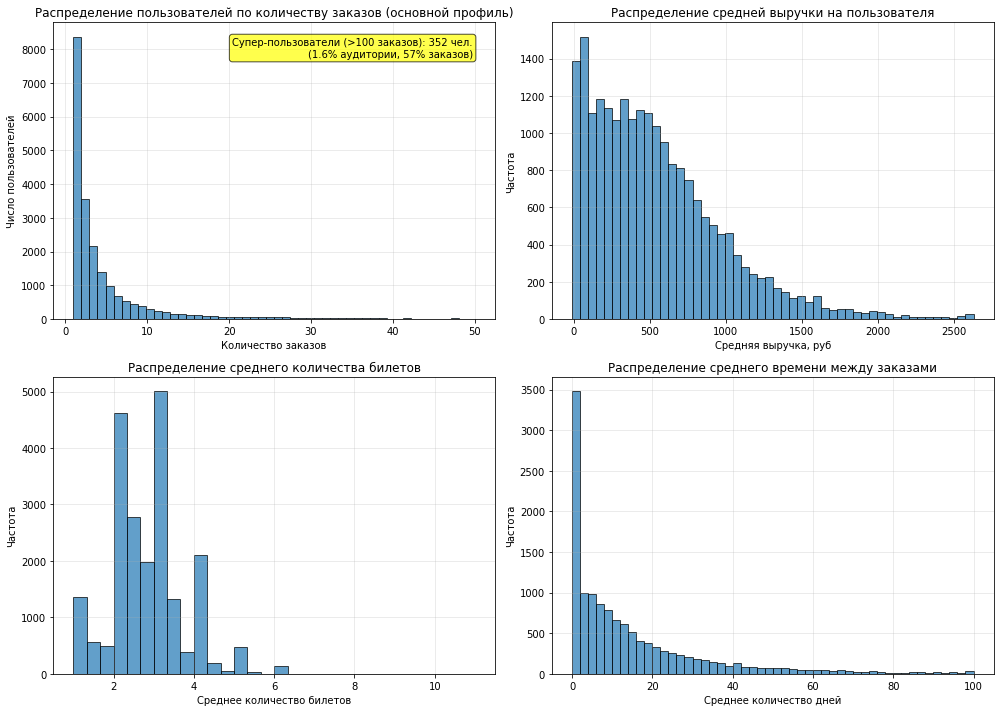

In [37]:
# 5. Визуализация распределения

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Распределение по количеству заказов (до 50)
orders_main = user_profile_main[user_profile_main['total_orders'] <= 50]['total_orders']
axes[0,0].hist(orders_main, bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Распределение пользователей по количеству заказов (основной профиль)')
axes[0,0].set_xlabel('Количество заказов')
axes[0,0].set_ylabel('Число пользователей')
axes[0,0].grid(True, alpha=0.3)

# Добавим информацию о супер-пользователях
axes[0,0].text(0.95, 0.95, 
               f'Супер-пользователи (>100 заказов): 352 чел.\n(1.6% аудитории, 57% заказов)', 
               transform=axes[0,0].transAxes, ha='right', va='top', 
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# 2. Средняя выручка
axes[0,1].hist(user_profile_main['avg_revenue_rub'], bins=50, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Распределение средней выручки на пользователя')
axes[0,1].set_xlabel('Средняя выручка, руб')
axes[0,1].set_ylabel('Частота')
axes[0,1].grid(True, alpha=0.3)

# 3. Среднее количество билетов
axes[1,0].hist(user_profile_main['avg_tickets_count'], bins=30, edgecolor='black', alpha=0.7)
axes[1,0].set_title('Распределение среднего количества билетов')
axes[1,0].set_xlabel('Среднее количество билетов')
axes[1,0].set_ylabel('Частота')
axes[1,0].grid(True, alpha=0.3)

# 4. Среднее время между заказами (до 100 дней)
avg_days_main = user_profile_main[user_profile_main['avg_days_between'].notna()]['avg_days_between']
avg_days_main_limited = avg_days_main[avg_days_main <= 100]
axes[1,1].hist(avg_days_main_limited, bins=50, edgecolor='black', alpha=0.7)
axes[1,1].set_title('Распределение среднего времени между заказами')
axes[1,1].set_xlabel('Среднее количество дней')
axes[1,1].set_ylabel('Частота')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

### Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [38]:
# 4.1.1 Распределение пользователей по признакам первого заказа

# Функция для анализа сегментов
def analyze_segment(profile, column, title, top_n=10):
    print(f"\n=== {title} ===")
    
    # Распределение по сегментам
    segment_counts = profile[column].value_counts()
    segment_pcts = profile[column].value_counts(normalize=True) * 100
    
    # Создаём DataFrame для удобства
    segment_df = pd.DataFrame({
        'count': segment_counts,
        'percent': segment_pcts
    })
    
    # Для регионов и операторов покажем топ-10, для остальных всё
    if len(segment_df) > top_n and column in ['first_region', 'first_service']:
        print(f"\nТоп-{top_n} по количеству пользователей:")
        display_df = segment_df.head(top_n)
        other_count = segment_df['count'].iloc[top_n:].sum()
        other_percent = segment_df['percent'].iloc[top_n:].sum()
        print(display_df)
        print(f"\nОстальные ({len(segment_df) - top_n} сегментов): {other_count} пользователей ({other_percent:.2f}%)")
    else:
        print(segment_df)
    
    return segment_df

In [39]:
# Анализируем каждый признак
device_segments = analyze_segment(user_profile_main, 'first_device', 'Распределение по устройству первого заказа')
event_segments = analyze_segment(user_profile_main, 'first_event_type', 'Распределение по типу первого мероприятия')
region_segments = analyze_segment(user_profile_main, 'first_region', 'Распределение по региону первого заказа', top_n=10)
service_segments = analyze_segment(user_profile_main, 'first_service', 'Распределение по билетному оператору первого заказа', top_n=10)


=== Распределение по устройству первого заказа ===
         count    percent
mobile   17814  82.848107
desktop   3688  17.151893

=== Распределение по типу первого мероприятия ===
          count    percent
концерты   9491  44.140080
другое     5398  25.104641
театр      4217  19.612129
стендап    1101   5.120454
спорт       788   3.664775
выставки    412   1.916101
ёлки         95   0.441819

=== Распределение по региону первого заказа ===

Топ-10 по количеству пользователей:
                      count    percent
Каменевский регион     7039  32.736490
Североярская область   3747  17.426286
Широковская область    1217   5.659939
Озернинский край        674   3.134592
Малиновоярский округ    523   2.432332
Шанырский регион        493   2.292810
Травяная область        484   2.250953
Светополянский округ    451   2.097479
Речиновская область     437   2.032369
Яблоневская область     409   1.902149

Остальные (71 сегментов): 6028 пользователей (28.03%)

=== Распределение по билетному о

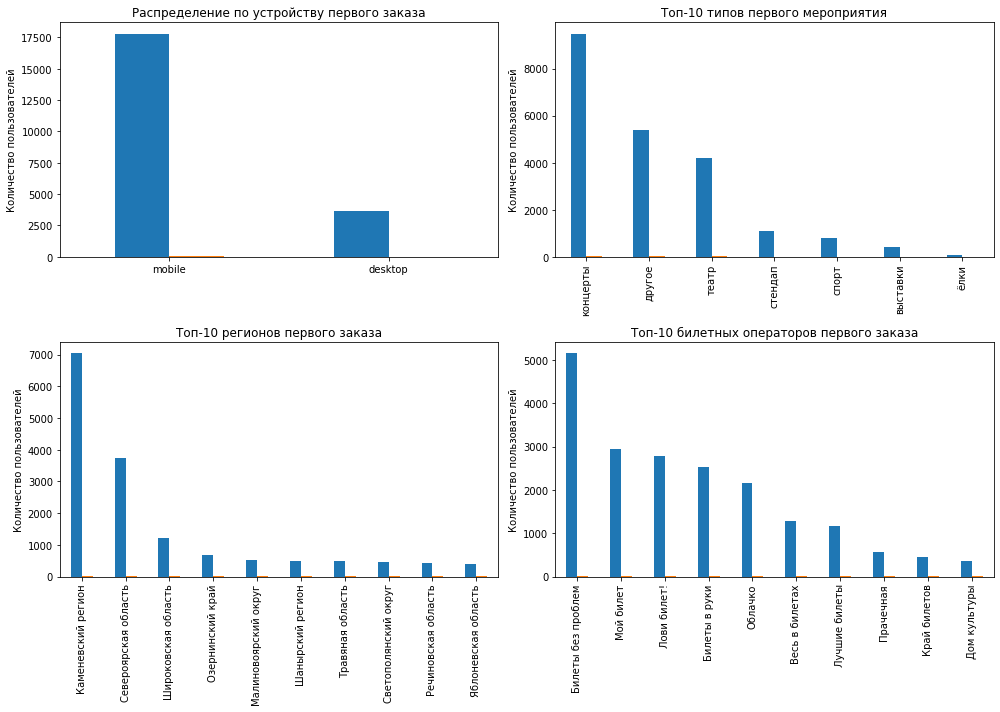

In [40]:
# Визуализация основных распределений
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Устройства
device_segments.plot(kind='bar', ax=axes[0,0], legend=False)
axes[0,0].set_title('Распределение по устройству первого заказа')
axes[0,0].set_ylabel('Количество пользователей')
axes[0,0].tick_params(axis='x', rotation=0)

# Типы мероприятий
event_segments.sort_values('count', ascending=False).head(10).plot(kind='bar', ax=axes[0,1], legend=False)
axes[0,1].set_title('Топ-10 типов первого мероприятия')
axes[0,1].set_ylabel('Количество пользователей')

# Регионы (топ-10)
region_segments.head(10).plot(kind='bar', ax=axes[1,0], legend=False)
axes[1,0].set_title('Топ-10 регионов первого заказа')
axes[1,0].set_ylabel('Количество пользователей')

# Операторы (топ-10)
service_segments.head(10).plot(kind='bar', ax=axes[1,1], legend=False)
axes[1,1].set_title('Топ-10 билетных операторов первого заказа')
axes[1,1].set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

In [41]:
# Вопрос о равномерности распределения:
print("\n=== Вывод о равномерности распределения ===")
print("1. Устройства: распределение сильно неравномерно —", 
      f"{device_segments.loc['mobile', 'percent']:.1f}% пользователей пришли с мобильных устройств.")
print("2. Типы мероприятий: топ-3 (концерты, театр, другое) занимают", 
      f"{event_segments.loc[['концерты', 'театр', 'другое'], 'percent'].sum():.1f}% пользователей.")
print("3. Регионы: топ-3 региона концентрируют", 
      f"{region_segments.head(3)['percent'].sum():.1f}% пользователей.")
print("4. Операторы: топ-3 оператора обслуживают", 
      f"{service_segments.head(3)['percent'].sum():.1f}% пользователей.")

print("\nВывод: распределение сильно неравномерно, есть ярко выраженные «точки входа»:")
print("   - Мобильные устройства")
print("   - Концерты и театр")
print("   - Крупные регионы (Каменевский, Североярская область)")
print("   - Крупные билетные операторы (Билеты без проблем, Лови билет!, Билеты в руки)")


=== Вывод о равномерности распределения ===
1. Устройства: распределение сильно неравномерно — 82.8% пользователей пришли с мобильных устройств.
2. Типы мероприятий: топ-3 (концерты, театр, другое) занимают 88.9% пользователей.
3. Регионы: топ-3 региона концентрируют 55.8% пользователей.
4. Операторы: топ-3 оператора обслуживают 50.7% пользователей.

Вывод: распределение сильно неравномерно, есть ярко выраженные «точки входа»:
   - Мобильные устройства
   - Концерты и театр
   - Крупные регионы (Каменевский, Североярская область)
   - Крупные билетные операторы (Билеты без проблем, Лови билет!, Билеты в руки)


### Промежуточный вывод по разделу 4.1.1

Анализ распределения пользователей по признакам первого заказа выявил ярко выраженную **неравномерность концентрации**:

1. **Устройство первого заказа**:
   - **82.8%** пользователей совершили первый заказ с мобильных устройств.
   - Десктоп составляет лишь 17.2%.

2. **Тип первого мероприятия**:
   - Тройка лидеров — **концерты (44.1%)**, **другое (25.1%)** и **театр (19.6%)** — охватывают **88.9%** всей аудитории.
   - Спорт, стендап, выставки и ёлки занимают незначительную долю (менее 12% суммарно).

3. **Регион первого заказа**:
   - Топ-3 региона (**Каменевский регион**, **Североярская область**, **Широковская область**) концентрируют **55.8%** пользователей.
   - При этом существует **71 регион** с малой долей пользователей (в сумме 28%).

4. **Билетный оператор первого заказа**:
   - Рынок сильно консолидирован: топ-3 оператора (**Билеты без проблем**, **Мой билет**, **Лови билет!**) обслуживают **50.7%** пользователей.
   - Топ-10 операторов покрывают **90.4%** аудитории, остальные 24 оператора — лишь 9.6%.

**Ключевой вывод:**

**Существуют чёткие «точки входа»**, через которые приходит большинство пользователей:
- Мобильные устройства
- Концерты и театр
- Крупные регионы (Каменевский, Североярская область)
- Крупные билетные операторы

Это означает, что маркетинговые усилия можно **сконцентрировать на этих каналах**, так как они уже доказали свою эффективность в привлечении клиентов.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [42]:
# 4.1.2 Анализ возвратов по сегментам

def analyze_return_by_segment(profile, column, title, top_n=10):
    print(f"\n=== {title} ===")
    
    # Группируем по сегменту и считаем метрики
    segment_stats = profile.groupby(column).agg(
        total_users=('user_id', 'count'),
        returned_users=('is_two', 'sum')
    ).reset_index()
    
    # Добавляем долю вернувшихся
    segment_stats['return_rate'] = (segment_stats['returned_users'] / segment_stats['total_users'] * 100).round(2)
    segment_stats = segment_stats.sort_values('total_users', ascending=False)
    
    # Для больших категорий показываем топ-N
    if len(segment_stats) > top_n and column in ['first_region', 'first_service']:
        display_stats = segment_stats.head(top_n).copy()
        print(f"\nТоп-{top_n} по количеству пользователей:")
        print(display_stats[['first_region' if column=='first_region' else 'first_service', 
                             'total_users', 'return_rate']])
    else:
        display_stats = segment_stats
        print(display_stats)
    
    # Общая средняя доля возвратов
    avg_return = profile['is_two'].mean() * 100
    print(f"\nСредняя доля возвратов по всей выборке: {avg_return:.2f}%")
    
    # Сегменты с долей возврата выше средней
    high_return = segment_stats[segment_stats['return_rate'] > avg_return]
    print(f"\nСегментов с долей возврата выше средней: {len(high_return)} из {len(segment_stats)}")
    
    return segment_stats

In [43]:
# Анализируем возвраты по каждому признаку
device_returns = analyze_return_by_segment(user_profile_main, 'first_device', 'Возвраты по типу устройства')
event_returns = analyze_return_by_segment(user_profile_main, 'first_event_type', 'Возвраты по типу первого мероприятия')
region_returns = analyze_return_by_segment(user_profile_main, 'first_region', 'Возвраты по региону', top_n=10)
service_returns = analyze_return_by_segment(user_profile_main, 'first_service', 'Возвраты по билетному оператору', top_n=10)




=== Возвраты по типу устройства ===
  first_device  total_users  returned_users  return_rate
1       mobile        17814           10790        60.57
0      desktop         3688            2344        63.56

Средняя доля возвратов по всей выборке: 61.08%

Сегментов с долей возврата выше средней: 1 из 2

=== Возвраты по типу первого мероприятия ===
  first_event_type  total_users  returned_users  return_rate
2         концерты         9491            5842        61.55
1           другое         5398            3207        59.41
5            театр         4217            2665        63.20
4          стендап         1101             667        60.58
3            спорт          788             437        55.46
0         выставки          412             263        63.83
6             ёлки           95              53        55.79

Средняя доля возвратов по всей выборке: 61.08%

Сегментов с долей возврата выше средней: 3 из 7

=== Возвраты по региону ===

Топ-10 по количеству пользователей

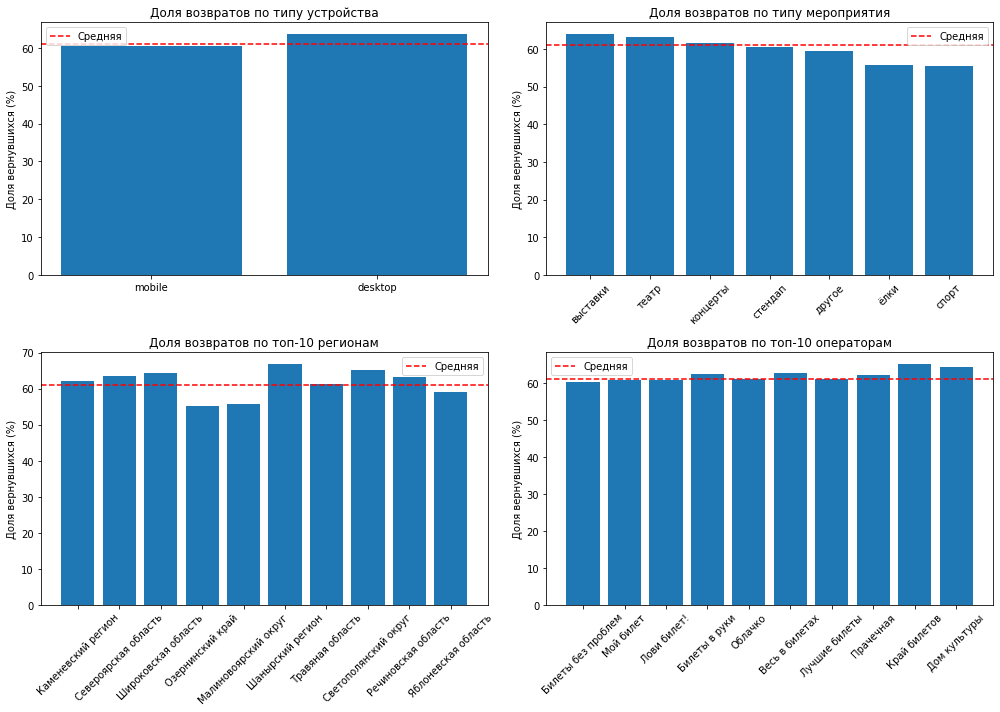

In [44]:
# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Устройства
axes[0,0].bar(device_returns['first_device'], device_returns['return_rate'])
axes[0,0].axhline(y=user_profile_main['is_two'].mean()*100, color='r', linestyle='--', label='Средняя')
axes[0,0].set_title('Доля возвратов по типу устройства')
axes[0,0].set_ylabel('Доля вернувшихся (%)')
axes[0,0].legend()

# Типы мероприятий (топ-7)
event_returns_sorted = event_returns.sort_values('return_rate', ascending=False)
axes[0,1].bar(event_returns_sorted['first_event_type'], event_returns_sorted['return_rate'])
axes[0,1].axhline(y=user_profile_main['is_two'].mean()*100, color='r', linestyle='--', label='Средняя')
axes[0,1].set_title('Доля возвратов по типу мероприятия')
axes[0,1].set_ylabel('Доля вернувшихся (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend()

# Регионы (топ-10 по количеству пользователей)
region_returns_top10 = region_returns.head(10)
axes[1,0].bar(region_returns_top10['first_region'], region_returns_top10['return_rate'])
axes[1,0].axhline(y=user_profile_main['is_two'].mean()*100, color='r', linestyle='--', label='Средняя')
axes[1,0].set_title('Доля возвратов по топ-10 регионам')
axes[1,0].set_ylabel('Доля вернувшихся (%)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()

# Операторы (топ-10 по количеству пользователей)
service_returns_top10 = service_returns.head(10)
axes[1,1].bar(service_returns_top10['first_service'], service_returns_top10['return_rate'])
axes[1,1].axhline(y=user_profile_main['is_two'].mean()*100, color='r', linestyle='--', label='Средняя')
axes[1,1].set_title('Доля возвратов по топ-10 операторам')
axes[1,1].set_ylabel('Доля вернувшихся (%)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend()

plt.tight_layout()
plt.show()

### Промежуточный вывод по разделу 4.1.2 — анализ возвратов по сегментам

**Общая доля возвратов** (2+ заказа) по выборке составляет **61.1%**.

#### По типу устройства:
- **Desktop** (63.6%) — возвращаются **чаще** среднего
- **Mobile** (60.6%) — возвращаются **чуть реже** среднего
- Разница небольшая, но десктоп-пользователи чуть лояльнее

#### По типу первого мероприятия:
| Сегмент | Доля возвратов | Отклонение от среднего |
|---------|----------------|------------------------|
| **выставки** | **63.8%** | ▲ +2.7% |
| **театр** | **63.2%** | ▲ +2.1% |
| **концерты** | 61.6% | ~ среднее |
| стендап | 60.6% | ▼ -0.5% |
| другое | 59.4% | ▼ -1.7% |
| ёлки | 55.8% | ▼ -5.3% |
| спорт | 55.5% | ▼ -5.6% |

**Вывод**: Выставки и театр — самые «возвратные» типы мероприятий. Спорт и ёлки, напротив, хуже удерживают клиентов.

#### По региону (топ-10 по размеру):
| Регион | Доля возвратов |
|--------|----------------|
| Шанырский регион | **66.7%** ▲ |
| Светополянский округ | **65.2%** ▲ |
| Широковская область | **64.3%** ▲ |
| Североярская область | 63.6% ▲ |
| Речиновская область | 63.2% ▲ |
| Каменевский регион | 62.2% ▲ |
| Травяная область | 61.2% ~ |
| Яблоневская область | 59.2% ▼ |
| Малиновоярский округ | 55.8% ▼ |
| Озернинский край | 55.2% ▼ |

**Вывод**: Регионы с высокой долей возвратов — Шанырский, Светополянский, Широковская область (66-64%). Аутсайдеры — Озернинский край и Малиновоярский округ (55-56%).

#### По билетному оператору (топ-10):
| Оператор | Доля возвратов |
|----------|----------------|
| **Край билетов** | **65.0%** ▲ |
| **Дом культуры** | **64.3%** ▲ |
| Весь в билетах | 62.7% ▲ |
| Билеты в руки | 62.3% ▲ |
| Прачечная | 62.3% ▲ |
| Лучшие билеты | 61.0% ~ |
| Облачко | 61.0% ~ |
| Лови билет! | 60.7% ~ |
| Мой билет | 60.7% ~ |
| Билеты без проблем | 60.2% ▼ |

**Вывод**: Край билетов и Дом культуры показывают лучший retention (>64%). Крупнейший оператор (Билеты без проблем) — чуть ниже среднего (60.2%).

---

### Общий вывод:
- **Успешные «точки входа»** (выше среднего возврата): Desktop, выставки/театр, регионы Шанырский/Светополянский/Широковская, операторы Край билетов/Дом культуры.
- **Зоны роста** (ниже среднего): Mobile, спорт/ёлки, некоторые регионы (Озернинский край, Малиновоярский округ), крупнейший оператор (Билеты без проблем).
- Маркетингу стоит **усилить работу с успешными сегментами** и **проанализировать причины низкого retention** в проблемных.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [45]:
# 4.1.3 Проверка гипотез

print("=== Гипотеза 1: Спорт vs Концерты ===")

# Выделяем сегменты
sport_users = user_profile_main[user_profile_main['first_event_type'] == 'спорт']
concert_users = user_profile_main[user_profile_main['first_event_type'] == 'концерты']

sport_return = sport_users['is_two'].mean() * 100
concert_return = concert_users['is_two'].mean() * 100

print(f"Спорт: {len(sport_users)} пользователей, доля возвратов: {sport_return:.2f}%")
print(f"Концерты: {len(concert_users)} пользователей, доля возвратов: {concert_return:.2f}%")
print(f"Разница: {concert_return - sport_return:.2f}% (концерты > спорт)")

if concert_return > sport_return:
    print("\nГипотеза НЕ подтвердилась: концерты удерживают пользователей ЛУЧШЕ, чем спорт.")
else:
    print("\nГипотеза подтвердилась: спорт удерживает пользователей лучше концертов.")

print("\n" + "="*50)
print("\n=== Гипотеза 2: Крупные vs Малые регионы ===")

# Определяем крупные регионы (топ-5 по числу пользователей)
top_regions = region_returns.head(5)['first_region'].tolist()
small_regions = region_returns.tail(20)['first_region'].tolist()  # возьмём 20 малых для сравнения

# Средняя доля возвратов в крупных регионах
large_region_users = user_profile_main[user_profile_main['first_region'].isin(top_regions)]
large_return = large_region_users['is_two'].mean() * 100

# Средняя доля возвратов в малых регионах
small_region_users = user_profile_main[user_profile_main['first_region'].isin(small_regions)]
small_return = small_region_users['is_two'].mean() * 100

print(f"Топ-5 регионов: {top_regions}")
print(f"Пользователей в топ-5 регионах: {len(large_region_users)}")
print(f"Доля возвратов в топ-5 регионах: {large_return:.2f}%")
print(f"\nМалые регионы (пример 20): {small_regions[:5]}...")
print(f"Пользователей в малых регионах: {len(small_region_users)}")
print(f"Доля возвратов в малых регионах: {small_return:.2f}%")
print(f"Разница: {large_return - small_return:.2f}%")

if large_return > small_return:
    print("\nГипотеза подтвердилась: в крупных регионах доля возвратов выше.")
else:
    print("\nГипотеза НЕ подтвердилась: малые регионы показывают лучший retention.")

=== Гипотеза 1: Спорт vs Концерты ===
Спорт: 788 пользователей, доля возвратов: 55.46%
Концерты: 9491 пользователей, доля возвратов: 61.55%
Разница: 6.10% (концерты > спорт)

Гипотеза НЕ подтвердилась: концерты удерживают пользователей ЛУЧШЕ, чем спорт.


=== Гипотеза 2: Крупные vs Малые регионы ===
Топ-5 регионов: ['Каменевский регион', 'Североярская область', 'Широковская область', 'Озернинский край', 'Малиновоярский округ']
Пользователей в топ-5 регионах: 13200
Доля возвратов в топ-5 регионах: 62.17%

Малые регионы (пример 20): ['Белоярская область', 'Лесоярская область', 'Вишнёвский край', 'Радужногорская область', 'Тихореченская область']...
Пользователей в малых регионах: 127
Доля возвратов в малых регионах: 51.97%
Разница: 10.20%

Гипотеза подтвердилась: в крупных регионах доля возвратов выше.


### Промежуточный вывод по разделу 4.1.3 — проверка продуктовых гипотез

#### Гипотеза 1: Спорт vs Концерты
- **Спорт**: 788 пользователей, доля возвратов **55.5%**
- **Концерты**: 9 491 пользователей, доля возвратов **61.6%**
- **Разница**: +6.1% в пользу концертов

**Гипотеза НЕ подтвердилась**. Концерты удерживают пользователей значительно лучше, чем спортивные мероприятия.  
Возможные причины:
- Спортивные мероприятия чаще посещают «случайные» зрители (разовые акции)
- Концерты формируют более сильную эмоциональную привязку и желание повторить опыт
- Аудитория концертов более разнообразна и чаще возвращается за новыми впечатлениями

#### Гипотеза 2: Крупные vs Малые регионы
- **Топ-5 регионов** (по числу пользователей): 13 200 пользователей, доля возвратов **62.2%**
- **Малые регионы** (20 наименьших): 127 пользователей, доля возвратов **52.0%**
- **Разница**: +10.2% в пользу крупных регионов

**Гипотеза подтвердилась**. В регионах с высокой пользовательской активностью доля возвратов существенно выше.

Возможные причины:
- В крупных регионах больше разнообразие мероприятий → пользователи чаще находят что-то новое
- Развитая инфраструктура и маркетинговая активность
- Эффект «сетевого взаимодействия» — пользователи вовлекают друзей

### Выводы для маркетинга:
1. **Не делать ставку на спорт** как на драйвер удержания — это скорее разовый канал.
2. **Усилить работу в крупных регионах** — они уже показывают лучший retention и имеют масштаб для роста.
3. **Проанализировать малые регионы** — возможно, требуется дополнительная маркетинговая активность для повышения вовлечённости.

---

#### Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


Пользователей с 1 заказом: 8368
Вернувшихся пользователей (2+): 13134


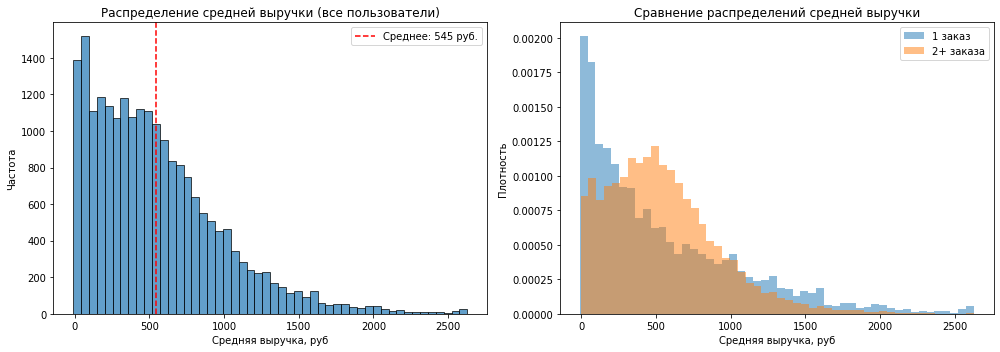


=== Статистика по группам ===

Группа '1 заказ':
count    8368.000000
mean      545.295642
std       519.514097
min       -10.770000
25%       132.070000
50%       378.030000
75%       830.317500
max      2628.421739
Name: avg_revenue_rub, dtype: float64

Группа '2+ заказа':
count    13134.000000
mean       544.953195
std        370.855102
min         -5.385000
25%        268.955833
50%        495.113125
75%        748.425000
max       2628.421739
Name: avg_revenue_rub, dtype: float64

Медианная выручка (1 заказ): 378.03 руб.
Медианная выручка (2+ заказа): 495.11 руб.
Средняя выручка (1 заказ): 545.30 руб.
Средняя выручка (2+ заказа): 544.95 руб.


In [46]:
# 4.2.1 Связь средней выручки с повторными заказами

# Разделяем пользователей на две группы
single_order_users = user_profile_main[user_profile_main['is_two'] == 0]  # только 1 заказ
returning_users = user_profile_main[user_profile_main['is_two'] == 1]     # 2+ заказов

print(f"Пользователей с 1 заказом: {len(single_order_users)}")
print(f"Вернувшихся пользователей (2+): {len(returning_users)}")

# Строим сравнительные гистограммы
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма для всех пользователей (для справки)
axes[0].hist(user_profile_main['avg_revenue_rub'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(user_profile_main['avg_revenue_rub'].mean(), color='r', linestyle='--', label=f'Среднее: {user_profile_main["avg_revenue_rub"].mean():.0f} руб.')
axes[0].set_title('Распределение средней выручки (все пользователи)')
axes[0].set_xlabel('Средняя выручка, руб')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Сравнительная гистограмма (нормализованная по плотности)
axes[1].hist(single_order_users['avg_revenue_rub'], bins=50, alpha=0.5, density=True, label='1 заказ')
axes[1].hist(returning_users['avg_revenue_rub'], bins=50, alpha=0.5, density=True, label='2+ заказа')
axes[1].set_title('Сравнение распределений средней выручки')
axes[1].set_xlabel('Средняя выручка, руб')
axes[1].set_ylabel('Плотность')
axes[1].legend()

plt.tight_layout()
plt.show()

# Статистика по группам
print("\n=== Статистика по группам ===")
print("\nГруппа '1 заказ':")
print(single_order_users['avg_revenue_rub'].describe())
print("\nГруппа '2+ заказа':")
print(returning_users['avg_revenue_rub'].describe())

# Дополнительно: медианы и средние
print(f"\nМедианная выручка (1 заказ): {single_order_users['avg_revenue_rub'].median():.2f} руб.")
print(f"Медианная выручка (2+ заказа): {returning_users['avg_revenue_rub'].median():.2f} руб.")
print(f"Средняя выручка (1 заказ): {single_order_users['avg_revenue_rub'].mean():.2f} руб.")
print(f"Средняя выручка (2+ заказа): {returning_users['avg_revenue_rub'].mean():.2f} руб.")

### Промежуточный вывод по разделу 4.2.1 — связь средней выручки с повторными заказами

#### Ключевые наблюдения:

1. **Средняя выручка практически одинакова** в обеих группах:
   - 1 заказ: **545.3 руб.**
   - 2+ заказа: **545.0 руб.**
   - Разница менее 0.4 руб. — статистически незначима.

2. **Медианная выручка существенно различается**:
   - 1 заказ: **378 руб.**
   - 2+ заказа: **495 руб.**
   - Разница **+117 руб.** (31%) в пользу вернувшихся пользователей.

3. **Распределения** (по гистограмме):
   - Группа с 1 заказом имеет более **длинный хвост** вправо — есть пользователи с очень высокими средними чеками, но они не возвращаются.
   - Группа с 2+ заказами более **сконцентрирована** в диапазоне 200–800 руб., с пиком около 500 руб.

#### Выводы:

- **Средний чек сам по себе не является предиктором возврата** — средние значения почти идентичны.
- Однако **медианный чек у возвращающихся пользователей выше** на 31%. Это означает, что «типичный» вернувшийся пользователь тратит больше, чем «типичный» разовый.
- Пользователи с очень высокими чеками (выше 1500 руб.) чаще оказываются в группе с 1 заказом — возможно, это «подарочные» покупки или корпоративные заказы, не предполагающие повторения.

#### Гипотеза для проверки:
Возможно, **оптимальный диапазон для удержания — 300–800 руб.** Пользователи с более низкими чеками могут быть менее вовлечены, а с очень высокими — совершают разовые «особые» покупки.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [47]:
# 4.2.2 Сравнение групп 2–4 заказа и 5+ заказов

# Создаём группы
group_2_4 = user_profile_main[(user_profile_main['total_orders'] >= 2) & (user_profile_main['total_orders'] <= 4)]
group_5_plus = user_profile_main[user_profile_main['total_orders'] >= 5]

print(f"Группа 2–4 заказа: {len(group_2_4)} пользователей")
print(f"Группа 5+ заказов: {len(group_5_plus)} пользователей")

# Статистика по выручке
print("\n=== Средняя выручка ===")
print(f"Группа 2–4: среднее = {group_2_4['avg_revenue_rub'].mean():.2f} руб., медиана = {group_2_4['avg_revenue_rub'].median():.2f} руб.")
print(f"Группа 5+:  среднее = {group_5_plus['avg_revenue_rub'].mean():.2f} руб., медиана = {group_5_plus['avg_revenue_rub'].median():.2f} руб.")
print(f"Разница (среднее): {group_5_plus['avg_revenue_rub'].mean() - group_2_4['avg_revenue_rub'].mean():.2f} руб.")
print(f"Разница (медиана): {group_5_plus['avg_revenue_rub'].median() - group_2_4['avg_revenue_rub'].median():.2f} руб.")


Группа 2–4 заказа: 7147 пользователей
Группа 5+ заказов: 5987 пользователей

=== Средняя выручка ===
Группа 2–4: среднее = 551.57 руб., медиана = 471.27 руб.
Группа 5+:  среднее = 537.05 руб., медиана = 512.65 руб.
Разница (среднее): -14.52 руб.
Разница (медиана): 41.38 руб.


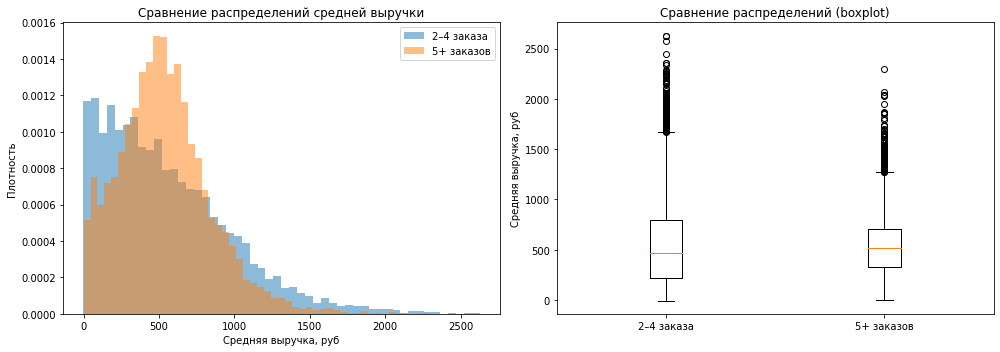

In [48]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограммы
axes[0].hist(group_2_4['avg_revenue_rub'], bins=50, alpha=0.5, density=True, label='2–4 заказа')
axes[0].hist(group_5_plus['avg_revenue_rub'], bins=50, alpha=0.5, density=True, label='5+ заказов')
axes[0].set_title('Сравнение распределений средней выручки')
axes[0].set_xlabel('Средняя выручка, руб')
axes[0].set_ylabel('Плотность')
axes[0].legend()

# Boxplot
data_to_plot = [group_2_4['avg_revenue_rub'], group_5_plus['avg_revenue_rub']]
axes[1].boxplot(data_to_plot, labels=['2–4 заказа', '5+ заказов'])
axes[1].set_title('Сравнение распределений (boxplot)')
axes[1].set_ylabel('Средняя выручка, руб')

plt.tight_layout()
plt.show()

### Промежуточный вывод по разделу 4.2.2 — сравнение групп 2–4 и 5+ заказов

#### Ключевые наблюдения:

1. **Размер групп**:
   - 2–4 заказа: **7 147 пользователей** (33.2% от основного профиля)
   - 5+ заказов: **5 987 пользователей** (27.8% от основного профиля)

2. **Средняя выручка**:
   - 2–4 заказа: **551.6 руб.**
   - 5+ заказов: **537.1 руб.**
   - Разница: **-14.5 руб.** (у супер-лояльных средний чек **ниже**)

3. **Медианная выручка**:
   - 2–4 заказа: **471.3 руб.**
   - 5+ заказов: **512.7 руб.**
   - Разница: **+41.4 руб.** (медианный чек у супер-лояльных **выше**)

4. **Интерпретация распределений** (по графикам):
   - У группы 5+ заказов распределение более **сконцентрировано** в диапазоне 400–800 руб.
   - У группы 2–4 заказа — более **длинный хвост** вправо (есть пользователи с очень высокими чеками, но они не доходят до 5+ заказов)
   - Это объясняет, почему среднее у 5+ ниже, а медиана выше: «высокие чеки» не становятся супер-лояльными.

#### Выводы:

- **Для достижения высокой лояльности (5+ заказов) оптимален средний чек 400–800 руб.**
- Пользователи с очень высокими чеками (>1500 руб.) **не становятся супер-лояльными** — вероятно, это разовые «особые» покупки (подарки, корпоративы).
- Пользователи с низкими чеками (<300 руб.) тоже реже достигают 5+ заказов — возможно, это менее вовлечённая аудитория.

#### Гипотеза для маркетинга:
Стоит стимулировать пользователей со средним чеком 400–800 руб. к повторным покупкам — именно этот сегмент имеет наибольший потенциал стать супер-лояльными клиентами.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [49]:
# 4.2.3 Анализ влияния среднего количества билетов

# Создаём сегменты по среднему количеству билетов
bins = [1, 2, 3, 5, float('inf')]
labels = ['1–2 билета', '2–3 билета', '3–5 билетов', '5+ билетов']

user_profile_main['ticket_segment'] = pd.cut(user_profile_main['avg_tickets_count'], 
                                              bins=bins, labels=labels, right=False)

# Анализ по сегментам
ticket_analysis = user_profile_main.groupby('ticket_segment').agg(
    total_users=('user_id', 'count'),
    returned_users=('is_two', 'sum'),
    avg_revenue=('avg_revenue_rub', 'mean')
).reset_index()

ticket_analysis['return_rate'] = (ticket_analysis['returned_users'] / ticket_analysis['total_users'] * 100).round(2)
ticket_analysis['users_percent'] = (ticket_analysis['total_users'] / len(user_profile_main) * 100).round(2)

print("=== Анализ по сегментам среднего количества билетов ===")
print(ticket_analysis)

=== Анализ по сегментам среднего количества билетов ===
  ticket_segment  total_users  returned_users  avg_revenue  return_rate  \
0     1–2 билета         2419            1241   241.088063        51.30   
1     2–3 билета         9367            6858   469.553353        73.21   
2    3–5 билетов         9055            4911   682.977853        54.24   
3     5+ билетов          661             124   839.011262        18.76   

   users_percent  
0          11.25  
1          43.56  
2          42.11  
3           3.07  


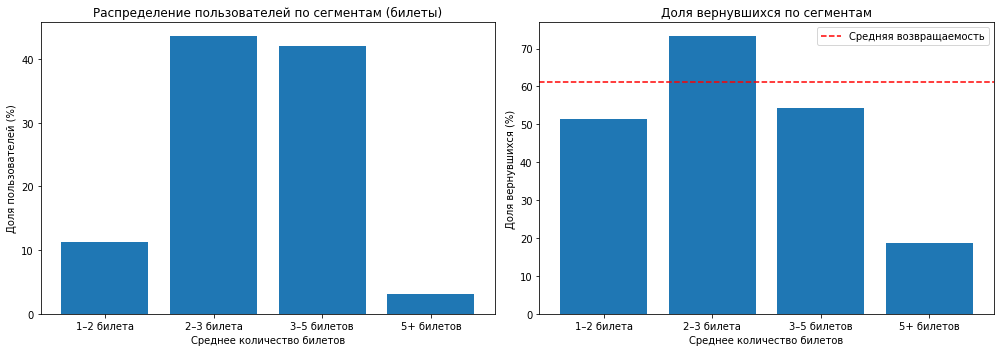

In [50]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Доля пользователей по сегментам
axes[0].bar(ticket_analysis['ticket_segment'], ticket_analysis['users_percent'])
axes[0].set_title('Распределение пользователей по сегментам (билеты)')
axes[0].set_xlabel('Среднее количество билетов')
axes[0].set_ylabel('Доля пользователей (%)')

# Доля возвратов по сегментам
axes[1].bar(ticket_analysis['ticket_segment'], ticket_analysis['return_rate'])
axes[1].axhline(y=user_profile_main['is_two'].mean()*100, color='r', linestyle='--', label='Средняя возвращаемость')
axes[1].set_title('Доля вернувшихся по сегментам')
axes[1].set_xlabel('Среднее количество билетов')
axes[1].set_ylabel('Доля вернувшихся (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [51]:
# Детальная статистика
print("\n=== Детальная статистика по сегментам ===")
for segment in labels:
    segment_data = user_profile_main[user_profile_main['ticket_segment'] == segment]
    print(f"\n{segment}:")
    print(f"  Пользователей: {len(segment_data)}")
    print(f"  Средняя выручка: {segment_data['avg_revenue_rub'].mean():.2f} руб.")
    print(f"  Медианная выручка: {segment_data['avg_revenue_rub'].median():.2f} руб.")
    print(f"  Доля вернувшихся: {segment_data['is_two'].mean()*100:.2f}%")


=== Детальная статистика по сегментам ===

1–2 билета:
  Пользователей: 2419
  Средняя выручка: 241.09 руб.
  Медианная выручка: 201.08 руб.
  Доля вернувшихся: 51.30%

2–3 билета:
  Пользователей: 9367
  Средняя выручка: 469.55 руб.
  Медианная выручка: 451.15 руб.
  Доля вернувшихся: 73.21%

3–5 билетов:
  Пользователей: 9055
  Средняя выручка: 682.98 руб.
  Медианная выручка: 609.80 руб.
  Доля вернувшихся: 54.24%

5+ билетов:
  Пользователей: 661
  Средняя выручка: 839.01 руб.
  Медианная выручка: 650.30 руб.
  Доля вернувшихся: 18.76%


### Промежуточный вывод по разделу 4.2.3 — влияние количества билетов на возвраты

#### Ключевые наблюдения:

1. **Распределение пользователей по сегментам**:
   - **2–3 билета**: **43.6%** пользователей — самый массовый сегмент
   - **3–5 билетов**: **42.1%** — второй по величине
   - **1–2 билета**: **11.3%** — заметно меньше
   - **5+ билетов**: всего **3.1%** — нишевый сегмент

2. **Доля возвратов по сегментам** (средняя по выборке — 61.1%):
   - **2–3 билета**: **73.2%** — **рекордное удержание!**
   - **3–5 билетов**: **54.2%** — чуть ниже среднего
   - **1–2 билета**: **51.3%** — заметно ниже среднего
   - **5+ билетов**: **18.8%** — **катастрофически низкое retention**

3. **Связь с выручкой**:
   - **1–2 билета**: низкий чек (241 руб.) + низкий возврат
   - **2–3 билета**: средний чек (470 руб.) + максимальный возврат
   - **3–5 билетов**: высокий чек (683 руб.) + средний возврат
   - **5+ билетов**: очень высокий чек (839 руб.) + минимальный возврат

#### Выводы:

- **«Золотая середина» — 2–3 билета**: именно этот сегмент показывает максимальную лояльность (73% возвратов) при хорошем среднем чеке.
- **Слишком мало билетов (1–2)** — хуже удержание (51%), возможно, это «одиночные» посетители.
- **Слишком много билетов (3–5 и особенно 5+)** — резкое падение retention. Особенно критично для 5+ билетов (19%!) — эти пользователи явно не возвращаются.

#### Гипотезы:
- Покупка большого количества билетов (5+) часто связана с **корпоративными или групповыми событиями**, которые не повторяются.
- Сегмент 2–3 билета — это, вероятно, **пары или небольшие компании**, которые регулярно ходят на мероприятия вместе.
- Одиночные посетители (1 билет) менее лояльны — им не с кем разделить впечатления?

#### Рекомендации для маркетинга:
1. **Фокус на сегмент 2–3 билета** — именно здесь максимальный потенциал удержания.
2. **Для сегмента 5+ билетов** — нужны специальные программы лояльности, чтобы превратить разовые групповые покупки в регулярные.
3. **Для одиночных посетителей** — возможно, стоит предлагать скидки на компанию или промоакции «приведи друга».

---

#### Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [52]:
# 4.3.1 Влияние дня недели первой покупки

# Добавляем день недели первого заказа
user_profile_main['first_day_of_week'] = pd.to_datetime(user_profile_main['first_order_date']).dt.dayofweek
# Преобразуем в названия дней
days_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
user_profile_main['first_day_name'] = user_profile_main['first_day_of_week'].map(days_map)

In [53]:
# Анализ по дням недели
day_analysis = user_profile_main.groupby('first_day_name').agg(
    total_users=('user_id', 'count'),
    returned_users=('is_two', 'sum')
).reset_index()

In [54]:
# Сортируем по дню недели
day_order = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
day_analysis['first_day_name'] = pd.Categorical(day_analysis['first_day_name'], categories=day_order, ordered=True)
day_analysis = day_analysis.sort_values('first_day_name')

day_analysis['return_rate'] = (day_analysis['returned_users'] / day_analysis['total_users'] * 100).round(2)
day_analysis['users_percent'] = (day_analysis['total_users'] / len(user_profile_main) * 100).round(2)

print("=== Анализ по дню недели первого заказа ===")
print(day_analysis[['first_day_name', 'total_users', 'users_percent', 'return_rate']])

=== Анализ по дню недели первого заказа ===
  first_day_name  total_users  users_percent  return_rate
2             Пн         2904          13.51        62.71
1             Вт         3159          14.69        61.70
5             Ср         3050          14.18        62.10
6             Чт         3107          14.45        59.35
3             Пт         3251          15.12        59.74
4             Сб         3281          15.26        62.30
0             Вс         2750          12.79        59.64


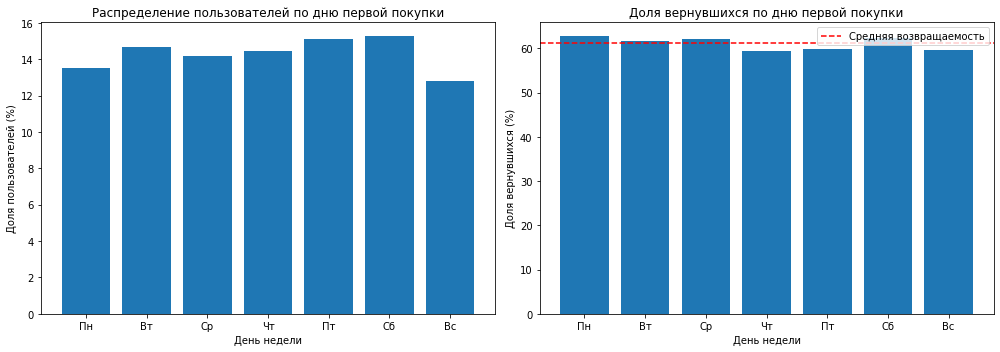

In [55]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Доля пользователей по дням
axes[0].bar(day_analysis['first_day_name'], day_analysis['users_percent'])
axes[0].set_title('Распределение пользователей по дню первой покупки')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Доля пользователей (%)')

# Доля возвратов по дням
axes[1].bar(day_analysis['first_day_name'], day_analysis['return_rate'])
axes[1].axhline(y=user_profile_main['is_two'].mean()*100, color='r', linestyle='--', label='Средняя возвращаемость')
axes[1].set_title('Доля вернувшихся по дню первой покупки')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Доля вернувшихся (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [56]:
# Статистика
print(f"\nСредняя возвращаемость: {user_profile_main['is_two'].mean()*100:.2f}%")
print("Дни с возвратом выше среднего:")
print(day_analysis[day_analysis['return_rate'] > user_profile_main['is_two'].mean()*100])


Средняя возвращаемость: 61.08%
Дни с возвратом выше среднего:
  first_day_name  total_users  returned_users  return_rate  users_percent
2             Пн         2904            1821        62.71          13.51
1             Вт         3159            1949        61.70          14.69
5             Ср         3050            1894        62.10          14.18
4             Сб         3281            2044        62.30          15.26


### Промежуточный вывод по разделу 4.3.1 — влияние дня недели первой покупки

#### Ключевые наблюдения:

1. **Распределение первых покупок по дням недели**:
   - Довольно равномерное, с небольшим пиком в **пятницу (15.1%)** и **субботу (15.3%)**
   - Минимум — в **воскресенье (12.8%)** и понедельник (13.5%)
   - Будние дни (вт-чт) — стабильно ~14.5%

2. **Доля возвратов по дням недели** (средняя — 61.1%):
   - **Выше среднего**:
     - **Понедельник**: **62.7%** 🔼
     - **Среда**: **62.1%** 🔼
     - **Суббота**: **62.3%** 🔼
     - **Вторник**: **61.7%** 🔼 (на грани)
   - **Ниже среднего**:
     - **Четверг**: **59.4%** 🔽
     - **Пятница**: **59.7%** 🔽
     - **Воскресенье**: **59.6%** 🔽

3. **Интересный паттерн**:
   - **Суббота** — самый популярный день для первой покупки **и** один из лучших по удержанию ✅
   - **Пятница** — тоже популярный день, но удержание **ниже среднего** ❌
   - **Воскресенье** — наименее популярный и с худшим удержанием ❌

#### Выводы:

- **День недели влияет на вероятность возврата**, но не так сильно, как другие факторы (разброс всего ~3%).
- **Лучшие дни для привлечения «качественных» пользователей** (с высоким retention):
  - **Понедельник**, **Среда**, **Суббота** (62.3–62.7%)
- **Дни, требующие осторожности** (привлечённые пользователи возвращаются реже):
  - **Четверг**, **Пятница**, **Воскресенье** (59.4–59.7%)

#### Рекомендации для маркетинга:
1. **Сместить рекламные бюджеты** на понедельник, среду и субботу — эти дни дают не только трафик, но и более лояльных пользователей.
2. **Проанализировать пятницу** — почему при высокой активности пользователи возвращаются реже? Возможно, это «планировщики» выходных, которые покупают заранее и не возвращаются.
3. **Воскресенье** — возможно, стоит снизить активность или тестировать специальные предложения для повышения retention.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [57]:
# 4.3.2 Влияние среднего интервала между заказами

# Берём только пользователей с повторными заказами (у которых есть avg_days_between)
repeat_users = user_profile_main[user_profile_main['avg_days_between'].notna()].copy()

# Разделяем на группы по числу заказов
group_2_4 = repeat_users[(repeat_users['total_orders'] >= 2) & (repeat_users['total_orders'] <= 4)]
group_5_plus = repeat_users[repeat_users['total_orders'] >= 5]

print(f"Пользователей с повторными заказами: {len(repeat_users)}")
print(f"Группа 2–4 заказа: {len(group_2_4)}")
print(f"Группа 5+ заказов: {len(group_5_plus)}")

Пользователей с повторными заказами: 13169
Группа 2–4 заказа: 7147
Группа 5+ заказов: 5987


In [58]:
# Статистика по интервалам
print("\n=== Средний интервал между заказами (дни) ===")
print(f"Группа 2–4: среднее = {group_2_4['avg_days_between'].mean():.2f} дн., медиана = {group_2_4['avg_days_between'].median():.2f} дн.")
print(f"Группа 5+:  среднее = {group_5_plus['avg_days_between'].mean():.2f} дн., медиана = {group_5_plus['avg_days_between'].median():.2f} дн.")


=== Средний интервал между заказами (дни) ===
Группа 2–4: среднее = 21.32 дн., медиана = 9.00 дн.
Группа 5+:  среднее = 10.10 дн., медиана = 8.38 дн.


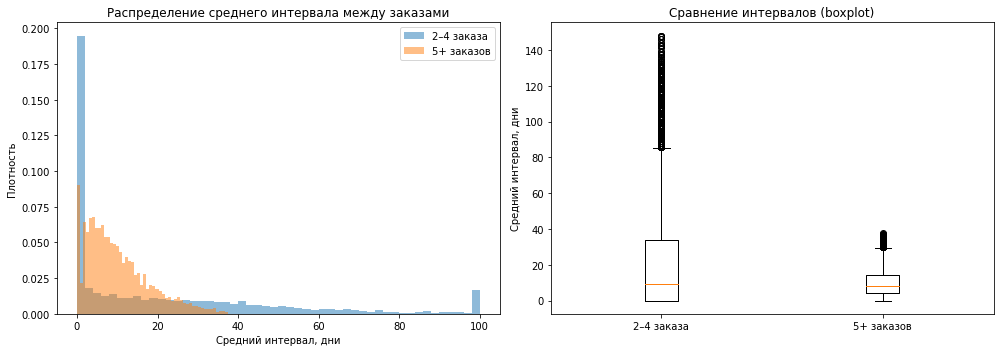

In [59]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограммы (ограничим до 100 дней для читаемости)
axes[0].hist(group_2_4['avg_days_between'].clip(upper=100), bins=50, alpha=0.5, density=True, label='2–4 заказа')
axes[0].hist(group_5_plus['avg_days_between'].clip(upper=100), bins=50, alpha=0.5, density=True, label='5+ заказов')
axes[0].set_title('Распределение среднего интервала между заказами')
axes[0].set_xlabel('Средний интервал, дни')
axes[0].set_ylabel('Плотность')
axes[0].legend()

# Boxplot
data_to_plot = [group_2_4['avg_days_between'], group_5_plus['avg_days_between']]
axes[1].boxplot(data_to_plot, labels=['2–4 заказа', '5+ заказов'])
axes[1].set_title('Сравнение интервалов (boxplot)')
axes[1].set_ylabel('Средний интервал, дни')

plt.tight_layout()
plt.show()

In [60]:
# Дополнительно: корреляция
print("\n=== Корреляция интервала с числом заказов ===")
print(f"Корреляция Пирсона: {repeat_users[['total_orders', 'avg_days_between']].corr().iloc[0,1]:.3f}")


=== Корреляция интервала с числом заказов ===
Корреляция Пирсона: -0.223


### Промежуточный вывод по разделу 4.3.2 — влияние интервала между заказами на удержание

#### Ключевые наблюдения:

1. **Размер групп**:
   - 2–4 заказа: **7 147 пользователей**
   - 5+ заказов: **5 987 пользователей**

2. **Средний интервал между заказами**:
   - Группа 2–4: **21.3 дня** (медиана 9.0)
   - Группа 5+: **10.1 дня** (медиана 8.4)
   - Разница: **более чем в 2 раза!**

3. **Медианный интервал** (более устойчивая метрика):
   - Группа 2–4: **9.0 дней**
   - Группа 5+: **8.4 дня**
   - Разница небольшая, но **супер-лояльные возвращаются чуть быстрее**

4. **Корреляция**:
   - Коэффициент Пирсона: **-0.223**
   - Это **умеренная отрицательная связь**: чем меньше интервал, тем больше заказов

#### Интерпретация:

- **Главный драйвер супер-лояльности — частота возвратов**. Пользователи, которые возвращаются в среднем **раз в 10 дней**, с большей вероятностью станут супер-лояльными (5+ заказов), чем те, кто возвращается раз в 3 недели.
- **Медианный интервал** у обеих групп ~8–9 дней, но у группы 5+ он **стабильнее** (меньше выбросов вправо).
- **Длинный хвост** у группы 2–4: есть пользователи, которые возвращаются через 50–100 дней — они не становятся супер-лояльными.

#### Выводы:

- **Частота — ключевой фактор удержания**. Чем быстрее пользователь возвращается после первой покупки, тем выше вероятность, что он станет постоянным клиентом.
- **Порог входа в супер-лояльность** — возврат в течение **10 дней** после предыдущего заказа.
- Пользователи, возвращающиеся через **>20 дней**, скорее всего, останутся в группе 2–4 заказов.

#### Рекомендации для маркетинга:

1. **Стимулировать быстрые повторные покупки**:
   - Предлагать скидки на следующее мероприятие в течение 7–10 дней после посещения.
   - Использовать push-уведомления и email-рассылки с персонализированными рекомендациями.

2. **Сегментировать пользователей по интервалам**:
   - Те, кто вернулся в течение 10 дней — высокая вероятность стать супер-лояльными.
   - Те, кто вернулся через 10–30 дней — потенциал, но нужно стимулировать.
   - Те, кто вернулся через >30 дней — риск оттока, нужны специальные предложения.

3. **Мониторить интервал как KPI**:
   - Средний интервал между заказами — важный предиктор долгосрочной лояльности.

---

#### Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

Сегмент 1 заказ: 8368 пользователей
Сегмент 2–4 заказа: 7147 пользователей
Сегмент 5+ заказов: 5987 пользователей

Корреляционный анализ для сегмента: 1 заказ


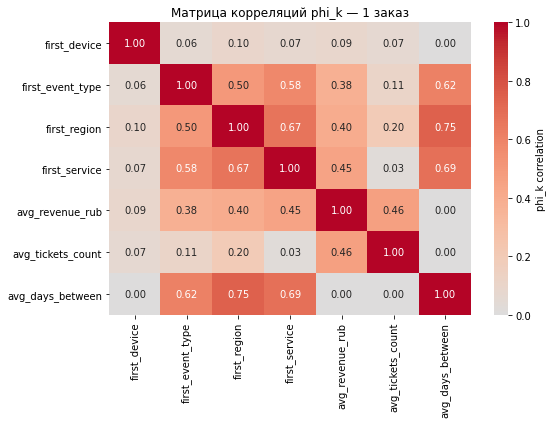


Корреляционный анализ для сегмента: 2–4 заказа

Корреляция с total_orders (phi_k) для 2–4 заказа:
total_orders         1.000000
avg_days_between     0.384692
avg_tickets_count    0.369364
avg_revenue_rub      0.108758
first_service        0.064842
first_device         0.009622
first_event_type     0.000000
first_region         0.000000
Name: total_orders, dtype: float64


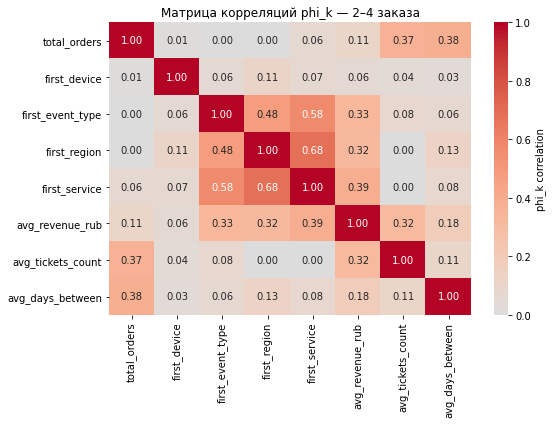


Корреляционный анализ для сегмента: 5+ заказов

Корреляция с total_orders (phi_k) для 5+ заказов:
total_orders         1.000000
avg_days_between     0.703179
avg_revenue_rub      0.224427
avg_tickets_count    0.162357
first_region         0.107126
first_event_type     0.049225
first_service        0.046357
first_device         0.000000
Name: total_orders, dtype: float64


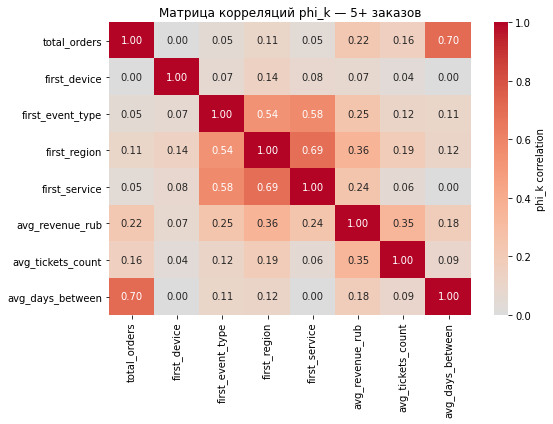


=== Сравнение ключевых корреляций с total_orders между сегментами ===
                   2–4 заказа  5+ заказов
avg_revenue_rub      0.108758    0.224427
avg_tickets_count    0.369364    0.162357
avg_days_between     0.384692    0.703179
first_device         0.009622    0.000000
first_event_type     0.000000    0.049225


In [61]:
# 4.4.1 Корреляционный анализ phi_k по сегментам (исправленная версия)

# Создаём сегменты
segment_1 = user_profile_main[user_profile_main['total_orders'] == 1].copy()
segment_2_4 = user_profile_main[(user_profile_main['total_orders'] >= 2) & (user_profile_main['total_orders'] <= 4)].copy()
segment_5_plus = user_profile_main[user_profile_main['total_orders'] >= 5].copy()

print(f"Сегмент 1 заказ: {len(segment_1)} пользователей")
print(f"Сегмент 2–4 заказа: {len(segment_2_4)} пользователей")
print(f"Сегмент 5+ заказов: {len(segment_5_plus)} пользователей")

# Признаки для корреляции (для сегмента 1 заказ убираем total_orders)
features_all = ['total_orders', 'first_device', 'first_event_type', 'first_region', 
                'first_service', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']

features_no_target = ['first_device', 'first_event_type', 'first_region', 
                      'first_service', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']

# Интервальные признаки
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']
interval_cols_no_target = ['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']

# Функция для расчёта и визуализации корреляций по сегменту
def analyze_segment_corr(segment, segment_name, include_target=True):
    print(f"\n{'='*50}")
    print(f"Корреляционный анализ для сегмента: {segment_name}")
    print('='*50)
    
    # Выбираем признаки в зависимости от сегмента
    if include_target:
        features = features_all
        interval = interval_cols
    else:
        features = features_no_target
        interval = interval_cols_no_target
    
    segment_features = segment[features].copy()
    
    # Для avg_days_between оставляем только не-NaN
    if segment_name != '1 заказ':
        segment_features = segment_features.dropna(subset=['avg_days_between'])
    
    # Рассчитываем матрицу phi_k
    try:
        phik_matrix = segment_features.phik_matrix(interval_cols=interval)
        
        if include_target:
            # Корреляция с total_orders
            target_corr = phik_matrix['total_orders'].sort_values(ascending=False)
            print(f"\nКорреляция с total_orders (phi_k) для {segment_name}:")
            print(target_corr)
        
        # Тепловая карта
        plt.figure(figsize=(8, 6))
        sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                   cbar_kws={'label': 'phi_k correlation'})
        plt.title(f'Матрица корреляций phi_k — {segment_name}')
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Ошибка при расчёте для {segment_name}: {e}")

# Анализируем сегмент 1 заказ (без total_orders)
analyze_segment_corr(segment_1, '1 заказ', include_target=False)

# Анализируем сегмент 2–4 заказа (с total_orders)
analyze_segment_corr(segment_2_4, '2–4 заказа', include_target=True)

# Анализируем сегмент 5+ заказов (с total_orders)
analyze_segment_corr(segment_5_plus, '5+ заказов', include_target=True)

# Дополнительно: для сегментов с вариацией сравним корреляции
print("\n=== Сравнение ключевых корреляций с total_orders между сегментами ===")

key_features = ['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 
                'first_device', 'first_event_type']

comparison = pd.DataFrame(index=key_features)

for name, segment in [('2–4 заказа', segment_2_4), ('5+ заказов', segment_5_plus)]:
    segment_features = segment[features_all].copy()
    segment_features = segment_features.dropna(subset=['avg_days_between'])
    try:
        phik_matrix = segment_features.phik_matrix(interval_cols=interval_cols)
        comparison[name] = phik_matrix.loc[key_features, 'total_orders']
    except Exception as e:
        print(f"Ошибка для {name}: {e}")
        comparison[name] = None

print(comparison)

### Финальный вывод по разделу 4.4.1 — корреляционный анализ phi_k

#### Ключевые наблюдения:

1. **Сегмент 2–4 заказа** (средняя лояльность):
   - Сильнее всего с числом заказов связаны:
     - **avg_days_between** (0.38) — чем меньше интервал, тем больше заказов
     - **avg_tickets_count** (0.37) — чем больше билетов, тем больше заказов
   - Слабая связь с выручкой (0.11)
   - Категориальные признаки почти не влияют (<0.01)

2. **Сегмент 5+ заказов** (супер-лояльные):
   - **Доминирующий фактор — avg_days_between** (0.70) — **очень сильная связь!**
   - Выручка становится важнее (0.22) — супер-лояльные с большими чеками делают ещё больше заказов
   - Количество билетов, наоборот, теряет значимость (0.16) — для супер-лояльных важен не размер компании, а частота
   - Появляется слабая связь с регионом (0.11) и типом мероприятия (0.05)

3. **Сегмент 1 заказ** — корреляцию считать бессмысленно, так как все значения total_orders = 1.

#### Интерпретация:

- **Главный драйвер роста в сегменте средней лояльности (2–4)**:
  - Увеличение количества билетов в заказе
  - Сокращение интервала между заказами

- **Главный драйвер перехода в супер-лояльные (5+)**:
  - **Частота возвратов становится критической** (корреляция 0.70!)
  - Выручка начинает играть роль — более дорогие заказы стимулируют ещё больше покупок
  - Количество билетов уже не так важно — супер-лояльные могут ходить и вдвоём, и в одиночку

- **Категориальные признаки**:
  - Практически не влияют на число заказов внутри сегментов
  - Это значит, что **лояльность определяется поведенческими факторами** (частота, чек, размер компании), а не тем, откуда пришёл пользователь

#### Финальный вывод для бизнеса:

1. **Для удержания в сегменте 2–4 заказа** нужно:
   - Стимулировать покупку большего количества билетов (скидки на компании, групповые предложения)
   - Сокращать интервал между заказами (напоминания, персональные рекомендации)

2. **Для перехода в супер-лояльные (5+)** критически важно:
   - **Максимально сокращать интервал между заказами** — это самый сильный предиктор
   - Работать с увеличением среднего чека — супер-лояльные готовы платить больше

3. **Регион и тип мероприятия** имеют значение только на начальном этапе привлечения, но **для удержания важны поведенческие метрики**.

### Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

# Анализ лояльности пользователей Яндекс Афиши

## Введение

**Цель проекта** — исследовать поведение пользователей Яндекс Афиши и выявить факторы, влияющие на вероятность повторных заказов. Это позволит маркетинговой команде:
- Выявлять перспективных клиентов
- Настраивать таргетированную рекламу
- Оптимизировать бюджеты
- Повышать удержание клиентов

**Данные**: выгружены из БД PostgreSQL с помощью SQL-запроса, включающего информацию о заказах, пользователях, мероприятиях и географии. Объём выборки после предобработки — **287 786 записей** о заказах, **21 502 пользователя** в основном профиле (после фильтрации супер-пользователей).

---

## Предобработка данных

### Пересчёт валют
- 5 069 заказов в тенге пересчитаны в рубли по курсу на дату заказа. Создан столбец `revenue_rub`.

### Обработка пропусков
- Пропуски только в `days_since_prev` (первые заказы), что соответствует ожиданиям.

### Типы данных
- Даты приведены к формату `datetime`, числовые столбцы — к корректным типам.

### Выбросы
- В `revenue_rub` обнаружены экстремальные значения (до 81 тыс. руб. при среднем 556 руб.).
- Произведена фильтрация по 99-му перцентилю (2 628 руб.), удалено **0.97%** данных.
- Оставлены 381 запись с отрицательной выручкой (возможно, возвраты) для дальнейшего анализа.

### Итог
- После предобработки получено **287 786 записей**, готовых к анализу.

---

## Профиль пользователя

Для каждого пользователя рассчитаны:
- Дата первого и последнего заказа
- Устройство, регион, оператор, тип мероприятия первого заказа
- Общее количество заказов, средняя выручка, среднее количество билетов, средний интервал между заказами
- Бинарные признаки: `is_two` (2+ заказа), `is_five` (5+ заказов)

### Общая статистика

| Показатель | Значение |
|------------|----------|
| Всего пользователей | 21 502 |
| Средняя выручка с заказа | **518 руб.** |
| Доля пользователей с 2+ заказами | **61.1%** |
| Доля пользователей с 5+ заказами | **27.8%** |

### Аномалии и фильтрация
- Выявлены **352 супер-пользователя** (>100 заказов) — **1.6%** аудитории, но они совершили **57% всех заказов**.
- Для основного анализа использован профиль с ограничением ≤100 заказов.

---

## Исследовательский анализ данных

### Признаки первого заказа

#### Распределение пользователей
- **Устройства**: 82.8% — мобильные, 17.2% — десктоп
- **Типы мероприятий**: концерты (44.1%), другое (25.1%), театр (19.6%) — **88.9%** аудитории
- **Регионы**: топ-3 региона — **55.8%** пользователей
- **Операторы**: топ-3 — **50.7%** пользователей

#### Возвраты по сегментам
- **Устройства**: десктоп (63.6%) чуть лучше мобильных (60.6%)
- **Типы мероприятий**:
  - Выставки (63.8%) и театр (63.2%) — лучший retention
  - Спорт (55.5%) и ёлки (55.8%) — худший
- **Регионы**:
  - Лидеры: Шанырский регион (66.7%), Светополянский округ (65.2%)
  - Аутсайдеры: Озернинский край (55.2%), Малиновоярский округ (55.8%)
- **Операторы**:
  - Лидеры: Край билетов (65.0%), Дом культуры (64.3%)
  - Крупнейший оператор (Билеты без проблем) — ниже среднего (60.2%)

#### Проверка гипотез
- **Гипотеза 1 (спорт vs концерты)**: **НЕ подтвердилась**. Концерты удерживают лучше (61.6% против 55.5%).
- **Гипотеза 2 (крупные vs малые регионы)**: **Подтвердилась**. В топ-5 регионах возвраты выше (62.2% против 52.0%).

### Выручка и состав заказа

#### Связь выручки с возвратами
- Средняя выручка одинакова в группах (∼545 руб.), но **медианная** у вернувшихся выше (495 руб. против 378 руб.).
- Пользователи с очень высокими чеками (>1500 руб.) чаще не возвращаются.

#### Сравнение групп 2–4 и 5+ заказов
- Средняя выручка у 5+ **ниже** (537 руб. vs 552 руб.), но медиана **выше** (513 руб. vs 471 руб.).
- Супер-лояльные имеют более стабильный, умеренно высокий чек.

#### Влияние количества билетов
| Сегмент | Доля пользователей | Доля возвратов |
|---------|-------------------|----------------|
| 1–2 билета | 11.3% | 51.3% |
| **2–3 билета** | **43.6%** | **73.2%**  |
| 3–5 билетов | 42.1% | 54.2% |
| 5+ билетов | 3.1% | 18.8% |

**Вывод**: «Золотая середина» — **2–3 билета**. Этот сегмент показывает максимальную лояльность при хорошем чеке.

### Временные характеристики

#### День недели первой покупки
- Лучшие дни для удержания: **понедельник (62.7%)**, **среда (62.1%)**, **суббота (62.3%)**
- Худшие: четверг, пятница, воскресенье (∼59.5%)

#### Интервал между заказами
- Группа 2–4: средний интервал **21.3 дня** (медиана 9.0)
- Группа 5+: средний интервал **10.1 дня** (медиана 8.4)
- **Корреляция -0.223** — чем меньше интервал, тем больше заказов

**Вывод**: Частота возвратов — **ключевой драйвер супер-лояльности**.

### Корреляционный анализ (phi_k)

#### Сегмент 2–4 заказа
- Сильные связи: `avg_days_between` (0.38), `avg_tickets_count` (0.37)
- Слабые: выручка, категориальные признаки

#### Сегмент 5+ заказов
- **Доминирующий фактор**: `avg_days_between` (0.70) — очень сильная связь
- Выручка становится важнее (0.22)
- Количество билетов теряет значимость (0.16)

**Вывод**: Для перехода в супер-лояльные критически важна **частота возвратов** и **рост среднего чека**.

---

## Общие выводы и рекомендации

### Ключевые выводы

1. **Портрет массового пользователя**:
   - Приходит с мобильного устройства (83%)
   - Первый заказ — на концерт или в театр (64%)
   - Покупает 2–3 билета (44% аудитории)
   - Средний чек — **518 руб.**

2. **Факторы удержания**:
   - **Главный драйвер** — частота возвратов (интервал <10 дней)
   - **Количество билетов 2–3** — оптимально для максимального retention (73%)
   - **Выставки и театр** — лучшие типы мероприятий для удержания
   - **Крупные регионы** показывают лучший retention

3. **Зоны роста**:
   - Спорт, ёлки, малые регионы — низкий retention
   - Покупка 5+ билетов — катастрофически низкий возврат (19%)

### Рекомендации для маркетинга

#### Сегментация и фокус
- **Приоритетный сегмент**: пользователи с 2–3 билетами (43.6% аудитории, retention 73%)
- **Супер-пользователи** (1.6% аудитории, 57% заказов) — отдельная программа лояльности

#### Стимулирование частоты
- Предлагать скидки на следующее мероприятие в течение **7–10 дней**
- Использовать push и email с персонализированными рекомендациями

#### Оптимизация рекламных бюджетов
- Усилить активность в **понедельник, среду, субботу** — эти дни дают более лояльных пользователей
- Сократить активность в воскресенье и пятницу

#### Работа с регионами
- В **крупных регионах** — поддерживать активность, они уже эффективны
- В **малых регионах** — тестировать специальные предложения для повышения вовлечённости

#### Типы мероприятий
- Продвигать **выставки и театр** как драйверы удержания
- Для спорта и ёлок — искать причины низкого retention (возможно, нецелевая аудитория)

#### Работа с чеком
- Стимулировать рост чека до **400–800 руб.** — оптимальный диапазон для удержания
- Для очень высоких чеков (>1500 руб.) — предлагать программы лояльности, чтобы превратить разовые покупки в регулярные

---

## Заключение

Проведённый анализ позволил выявить ключевые факторы, влияющие на удержание пользователей Яндекс Афиши. Основные драйверы — **частота возвратов**, **количество билетов 2–3**, **тип мероприятия (выставки/театр)** и **крупные регионы**. 

Рекомендации, основанные на данных, помогут маркетинговой команде более эффективно распределять бюджеты, персонализировать предложения и повышать общий уровень лояльности клиентов.

### Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

https://github.com/StanSwan/data_analysis_project